In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Lectura del archivo de candidatos
df = pd.read_csv('../data/candidates.csv')

# Criterio de contratación: puntuación de prueba y entrevista >= 7
df['is_hired'] = ((df['Code Challenge Score'] >= 7) & (df['Technical Interview'] >= 7)).astype(int)

# Limpieza básica de faltantes
df['Seniority'] = df['Seniority'].fillna('Desconocido')
df['Email'] = df['Email'].fillna('sin_correo@dominio.com')
df['Application Date'] = pd.to_datetime(df['Application Date'])

# Construcción de dimensiones
dim_tech = pd.DataFrame({'technology_name': df['Technology'].unique()}).reset_index(names='technology_id')
dim_seniority = pd.DataFrame({'seniority_level': df['Seniority'].unique()}).reset_index(names='seniority_id')
dim_location = pd.DataFrame({'country': df['Country'].unique()}).reset_index(names='location_id')

dim_date = pd.DataFrame({'full_date': df['Application Date'].drop_duplicates()}).sort_values('full_date').reset_index(drop=True)
dim_date['date_id'] = dim_date['full_date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year'] = dim_date['full_date'].dt.year
dim_date['month'] = dim_date['full_date'].dt.month
dim_date['day'] = dim_date['full_date'].dt.day

dim_candidate = df[['First Name', 'Last Name', 'Email']].drop_duplicates().reset_index(drop=True)
dim_candidate.index.name = 'candidate_id'
dim_candidate = dim_candidate.reset_index()
dim_candidate['candidate_id'] = dim_candidate['candidate_id'] + 1

# Mapeo de IDs hacia la tabla de hechos
df['date_id'] = df['Application Date'].dt.strftime('%Y%m%d').astype(int)

df_merged = df.merge(dim_tech, left_on='Technology', right_on='technology_name') \
              .merge(dim_seniority, left_on='Seniority', right_on='seniority_level') \
              .merge(dim_location, left_on='Country', right_on='country') \
              .merge(dim_candidate, on=['First Name', 'Last Name', 'Email'])

fact_apps = df_merged[[
    'candidate_id', 'technology_id', 'seniority_id', 'location_id', 
    'date_id', 'Yoe', 'Code Challenge Score', 'Technical Interview', 'is_hired'
]].copy()
fact_apps.index.name = 'application_id'
fact_apps = fact_apps.reset_index()

# Persistencia en SQLite
db = create_engine('sqlite:///../dw_candidates.db')

dim_tech.to_sql('dim_technology', db, if_exists='replace', index=False)
dim_seniority.to_sql('dim_seniority', db, if_exists='replace', index=False)
dim_location.to_sql('dim_location', db, if_exists='replace', index=False)
dim_date.to_sql('dim_date', db, if_exists='replace', index=False)
dim_candidate.to_sql('dim_candidate', db, if_exists='replace', index=False)
fact_apps.to_sql('fact_applications', db, if_exists='replace', index=False)

print("Datos procesados y cargados correctamente en SQLite.")

Datos procesados y cargados correctamente en SQLite.


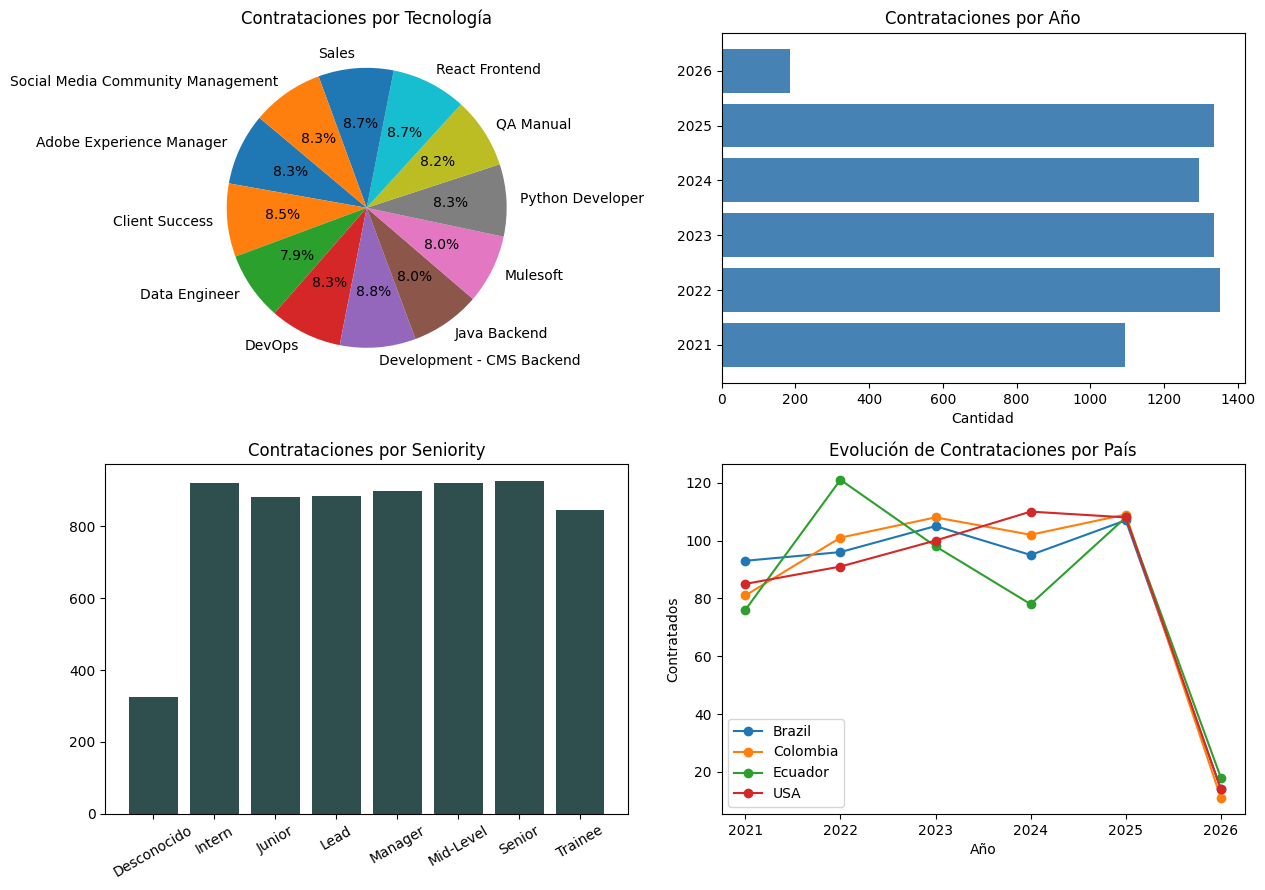

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

db = create_engine('sqlite:///../dw_candidates.db')

# Consultas para los gráficos
tech_df = pd.read_sql("SELECT t.technology_name, COUNT(*) AS contratados FROM fact_applications f JOIN dim_technology t ON f.technology_id = t.technology_id WHERE f.is_hired = 1 GROUP BY t.technology_name", db)
year_df = pd.read_sql("SELECT d.year, COUNT(*) AS contratados FROM fact_applications f JOIN dim_date d ON f.date_id = d.date_id WHERE f.is_hired = 1 GROUP BY d.year ORDER BY d.year ASC", db)
sen_df = pd.read_sql("SELECT s.seniority_level, COUNT(*) AS contratados FROM fact_applications f JOIN dim_seniority s ON f.seniority_id = s.seniority_id WHERE f.is_hired = 1 GROUP BY s.seniority_level", db)
country_df = pd.read_sql("SELECT l.country, d.year, COUNT(*) AS contratados FROM fact_applications f JOIN dim_location l ON f.location_id = l.location_id JOIN dim_date d ON f.date_id = d.date_id WHERE f.is_hired = 1 AND l.country IN ('USA', 'Brazil', 'Colombia', 'Ecuador') GROUP BY l.country, d.year ORDER BY d.year ASC", db)

# Renderizado de figuras
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].pie(tech_df['contratados'], labels=tech_df['technology_name'], autopct='%1.1f%%', startangle=140)
axes[0, 0].set_title('Contrataciones por Tecnología')

axes[0, 1].barh(year_df['year'].astype(str), year_df['contratados'], color='steelblue')
axes[0, 1].set_title('Contrataciones por Año')
axes[0, 1].set_xlabel('Cantidad')

axes[1, 0].bar(sen_df['seniority_level'], sen_df['contratados'], color='darkslategray')
axes[1, 0].set_title('Contrataciones por Seniority')
axes[1, 0].tick_params(axis='x', rotation=30)

for c in country_df['country'].unique():
    data = country_df[country_df['country'] == c]
    axes[1, 1].plot(data['year'], data['contratados'], marker='o', label=c)

axes[1, 1].set_title('Evolución de Contrataciones por País')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Contratados')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../docs/kpi_visualizations.png')
plt.show()